In [1]:
import os

# Set working directory to project root always
# Works regardless of where the notebook is saved
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
os.chdir(project_root)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\DELL\OneDrive\Documents\SRM\Churn_Analysis


In [2]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression

X_train = np.load(
    'outputs/X_train_banking.npy'
)

X_test = np.load(
    'outputs/X_test_banking.npy'
)

y_train = np.load(
    'outputs/y_train_banking.npy'
)

y_test = np.load(
    'outputs/y_test_banking.npy'
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (12740, 10)
Test Shape : (2000, 10)


In [3]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train,
    y_train
)

print(
    "Banking Logistic Regression trained successfully."
)

Banking Logistic Regression trained successfully.


In [4]:
y_pred = lr_model.predict(X_test)

y_proba = lr_model.predict_proba(
    X_test
)[:,1]

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

acc = accuracy_score(
    y_test,
    y_pred
)

prec = precision_score(
    y_test,
    y_pred
)

rec = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_proba
)

print("="*40)
print("Banking - Logistic Regression")
print("="*40)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("="*40)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            'Retained',
            'Exited'
        ]
    )
)

Banking - Logistic Regression
Accuracy  : 0.7095
Precision : 0.3827
Recall    : 0.6978
F1 Score  : 0.4943
ROC-AUC   : 0.7670
              precision    recall  f1-score   support

    Retained       0.90      0.71      0.80      1593
      Exited       0.38      0.70      0.49       407

    accuracy                           0.71      2000
   macro avg       0.64      0.71      0.65      2000
weighted avg       0.80      0.71      0.73      2000



<Figure size 600x500 with 0 Axes>

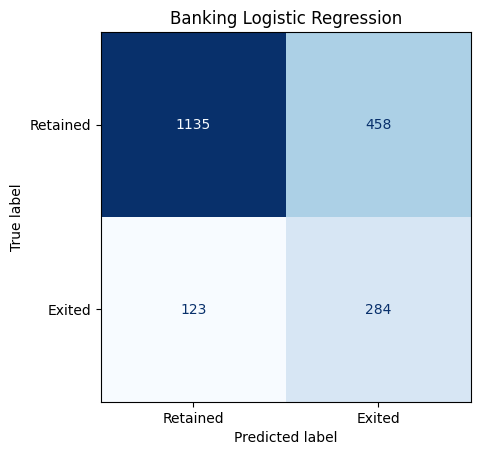

In [6]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'Retained',
        'Exited'
    ]
)

plt.figure(figsize=(6,5))

disp.plot(
    cmap='Blues',
    colorbar=False
)

plt.title(
    'Banking Logistic Regression'
)

plt.show()

<Figure size 600x500 with 0 Axes>

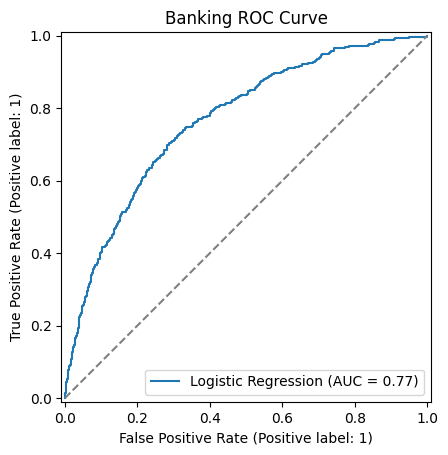

In [7]:
from sklearn.metrics import (
    RocCurveDisplay
)

plt.figure(figsize=(6,5))

RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    name='Logistic Regression'
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='gray'
)

plt.title(
    'Banking ROC Curve'
)

plt.show()

In [8]:
import joblib

joblib.dump(
    lr_model,
    'outputs/lr_model_banking.pkl'
)

print(
    "Model saved successfully."
)

Model saved successfully.


In [9]:
results = {
    'Sector'    : 'Banking',
    'Model'     : 'Logistic Regression',
    'Accuracy'  : round(acc,4),
    'Precision' : round(prec,4),
    'Recall'    : round(rec,4),
    'F1'        : round(f1,4),
    'ROC_AUC'   : round(auc,4)
}

results_df = pd.DataFrame(
    [results]
)

results_df.to_csv(
    'outputs/results/banking_lr_results.csv',
    index=False
)

print(results_df)

    Sector                Model  Accuracy  Precision  Recall      F1  ROC_AUC
0  Banking  Logistic Regression    0.7095     0.3827  0.6978  0.4943    0.767
